# E1 — Population Phase Transition and Finite-Sample Validation

**Paper question:** Can misaligned augmentation consistency make an unsupervised clustering
objective prefer a less-clusterable nuisance direction over a more-clusterable semantic direction?


> **Research-integrity note.** This notebook is intended to be rerun and inspected by the authors.
> Do not report results until you have run the full notebook yourself, checked the outputs,
> and can explain the method and code. Keep the exact notebook version and raw outputs used
> in the paper. Follow the conference/institution policy on disclosure of AI-assisted coding.


### Locked paper-facing design
- Semantic clusterability: `kappa_S = 0.60`
- Nuisance clusterability: `kappa_N = 0.10`
- Therefore `kappa_N < kappa_S`.
- Main quantity: `gamma = lambda * (alpha - q)`.
- Primary result: semantic drift → critical competition → nuisance collapse.
- S/N labels are used only for evaluation, never for optimization.

This notebook replaces the exploratory name **Experiment 05** with the paper-facing ID **E1**.

In [6]:
from pathlib import Path
import json, platform, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import ndtr

OUT = Path("/kaggle/working/E1_population_phase_transition")
OUT.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "experiment_id": "E1",
    "kappa_s": 0.60,
    "kappa_n": 0.10,
    "theta_points": 1441,
    "mc_population_n": 400000,
    "population_seed": 777,
    "finite_sample_sizes": [500, 1000, 5000],
    "finite_seeds": 80,
    "gamma_grid_finite": [0.00, 0.02, 0.04, 0.06, 0.07, 0.073, 0.08, 0.10],
}
(OUT/"config.json").write_text(json.dumps(CONFIG, indent=2))

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Output:", OUT)
print(json.dumps(CONFIG, indent=2))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
Output: /kaggle/working/E1_population_phase_transition
{
  "experiment_id": "E1",
  "kappa_s": 0.6,
  "kappa_n": 0.1,
  "theta_points": 1441,
  "mc_population_n": 400000,
  "population_seed": 777,
  "finite_sample_sizes": [
    500,
    1000,
    5000
  ],
  "finite_seeds": 80,
  "gamma_grid_finite": [
    0.0,
    0.02,
    0.04,
    0.06,
    0.07,
    0.073,
    0.08,
    0.1
  ]
}


## 1. Population objective

For
\[
X_1=\sqrt{\kappa_S}S+\sqrt{1-\kappa_S}Z_1,\quad
X_2=\sqrt{\kappa_N}N+\sqrt{1-\kappa_N}Z_2,
\]
we use the projection \(Y_\theta=\cos\theta X_1+\sin\theta X_2\).

The population distortion is
\[
D(\theta)=1-m_\theta^2,\quad m_\theta=E|Y_\theta|.
\]

For the sign-flip augmentation model, the theta-dependent consistency contribution is
\[
\gamma H(\theta),\quad \gamma=\lambda(lpha-q),
\]
up to an additive constant independent of \(\theta\).

In [7]:
def folded_normal_mean(mu, tau):
    mu = np.asarray(mu, dtype=float)
    tau = np.asarray(tau, dtype=float)
    mu, tau = np.broadcast_arrays(mu, tau)
    out = np.empty_like(mu)
    zero = tau <= 1e-12
    out[zero] = np.abs(mu[zero])
    z = np.abs(mu[~zero]) / tau[~zero]
    out[~zero] = (
        tau[~zero] * np.sqrt(2/np.pi) * np.exp(-0.5*z*z)
        + np.abs(mu[~zero]) * (2*ndtr(z)-1)
    )
    return out

def m_theta(theta, ks, kn):
    c, s = np.cos(theta), np.sin(theta)
    a = np.sqrt(ks)*c
    b = np.sqrt(kn)*s
    tau = np.sqrt((1-ks)*c*c + (1-kn)*s*s)
    return 0.5*folded_normal_mean(a+b,tau) + 0.5*folded_normal_mean(a-b,tau)

def distortion(theta, ks, kn):
    return 1 - m_theta(theta, ks, kn)**2

def estimate_H(theta, ks, kn, n, seed):
    rng = np.random.default_rng(seed)
    S = rng.choice([-1.,1.], n)
    N = rng.choice([-1.,1.], n)
    X1 = np.sqrt(ks)*S + np.sqrt(1-ks)*rng.normal(size=n)
    X2 = np.sqrt(kn)*N + np.sqrt(1-kn)*rng.normal(size=n)
    out=[]
    for i in range(0,len(theta),100):
        th=theta[i:i+100]
        out.append(np.mean(
            np.abs(np.cos(th)[:,None]*X1) > np.abs(np.sin(th)[:,None]*X2),
            axis=1
        ))
    return np.concatenate(out)

In [8]:
ks, kn = CONFIG["kappa_s"], CONFIG["kappa_n"]
theta = np.linspace(0, np.pi/2, CONFIG["theta_points"])
D = distortion(theta, ks, kn)
H = estimate_H(theta, ks, kn, CONFIG["mc_population_n"], CONFIG["population_seed"])

assert D[0] < D[-1], "Design failure: semantic axis must have lower base distortion."
print("D_semantic =", D[0])
print("D_nuisance =", D[-1])
print("Nuisance distortion disadvantage =", D[-1]-D[0])

D_semantic = 0.29097865929996225
D_nuisance = 0.36222705631110674
Nuisance distortion disadvantage = 0.0712483970111445


Conservative collapse threshold gamma_c (theta>=80°): 0.07279999999999999


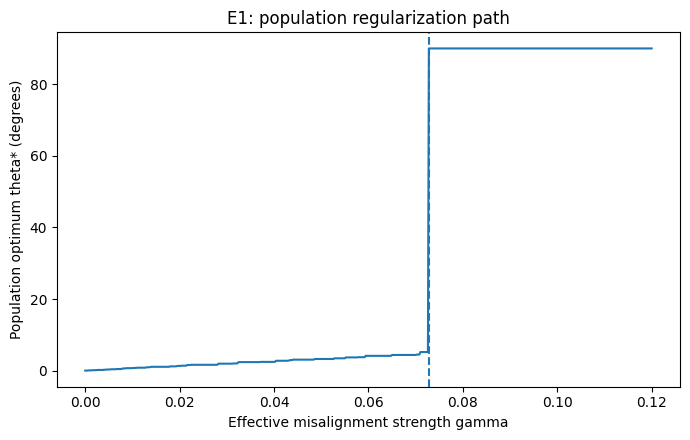

In [9]:
gammas = np.linspace(0, 0.12, 601)
rows=[]
for gamma in gammas:
    idx = int(np.argmin(D + gamma*H))
    rows.append({"gamma":gamma, "theta_star_deg":np.degrees(theta[idx])})
path = pd.DataFrame(rows)
path.to_csv(OUT/"population_regularization_path.csv", index=False)

hit = path[path.theta_star_deg >= 80]
gamma_c = float(hit.iloc[0].gamma) if len(hit) else np.nan
print("Conservative collapse threshold gamma_c (theta>=80°):", gamma_c)

plt.figure(figsize=(7,4.5))
plt.plot(path.gamma, path.theta_star_deg)
plt.axvline(gamma_c, linestyle="--")
plt.xlabel("Effective misalignment strength gamma")
plt.ylabel("Population optimum theta* (degrees)")
plt.title("E1: population regularization path")
plt.tight_layout()
plt.savefig(OUT/"E1_population_regularization_path.png", dpi=200)
plt.show()

## 2. Finite-sample empirical minimization

This section tests whether empirical minimizers converge toward the population transition,
including instability near the critical boundary.

In [10]:
def empirical_D_H(X1,X2,theta):
    Ds,Hs=[],[]
    for i in range(0,len(theta),120):
        th=theta[i:i+120]
        c=np.cos(th)[:,None]; s=np.sin(th)[:,None]
        Y=c*X1[None,:]+s*X2[None,:]
        m=np.mean(np.abs(Y),axis=1)
        Ds.append(np.mean(Y*Y,axis=1)-m*m)
        Hs.append(np.mean(np.abs(c*X1[None,:])>np.abs(s*X2[None,:]),axis=1))
    return np.concatenate(Ds), np.concatenate(Hs)

theta_emp=np.linspace(0,np.pi/2,361)
runs=[]
for n in CONFIG["finite_sample_sizes"]:
    for seed in range(CONFIG["finite_seeds"]):
        rng=np.random.default_rng(20000+n*10+seed)
        S=rng.choice([-1.,1.],n); N=rng.choice([-1.,1.],n)
        X1=np.sqrt(ks)*S+np.sqrt(1-ks)*rng.normal(size=n)
        X2=np.sqrt(kn)*N+np.sqrt(1-kn)*rng.normal(size=n)
        Dh,Hh=empirical_D_H(X1,X2,theta_emp)
        for gamma in CONFIG["gamma_grid_finite"]:
            idx=int(np.argmin(Dh+gamma*Hh))
            runs.append({
                "n":n,"seed":seed,"gamma":gamma,
                "theta_hat_deg":np.degrees(theta_emp[idx]),
                "collapse_80deg":float(np.degrees(theta_emp[idx])>=80)
            })
runs=pd.DataFrame(runs)
runs.to_csv(OUT/"finite_sample_runs.csv",index=False)

summary=runs.groupby(["n","gamma"]).agg(
    median_theta_deg=("theta_hat_deg","median"),
    p_nuisance_collapse=("collapse_80deg","mean")
).reset_index()
summary.to_csv(OUT/"finite_sample_summary.csv",index=False)
summary

,n,gamma,median_theta_deg,p_nuisance_collapse
0,500,0.000,0.250,0.0250
1,500,0.020,2.000,0.0625
2,500,0.040,3.750,0.1250
3,500,0.060,9.250,0.3500
4,500,0.070,12.625,0.4250
5,500,0.073,32.250,0.4625
6,500,0.080,89.875,0.6250
7,500,0.100,90.000,0.7750
8,1000,0.000,0.250,0.0000
9,1000,0.020,1.875,0.0625


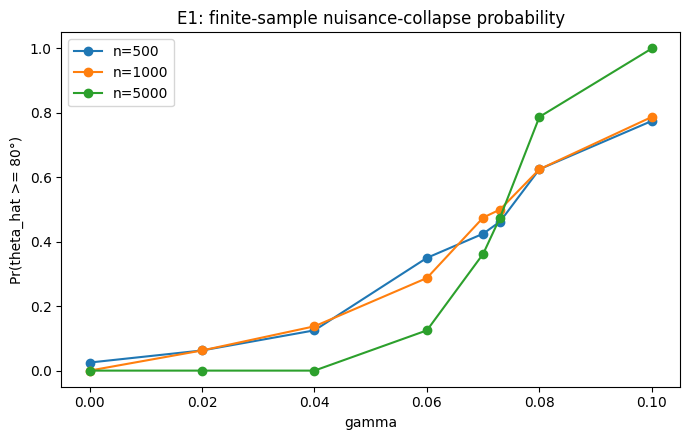

In [11]:
plt.figure(figsize=(7,4.5))
for n in CONFIG["finite_sample_sizes"]:
    s=summary[summary.n==n]
    plt.plot(s.gamma,s.p_nuisance_collapse,marker="o",label=f"n={n}")
plt.xlabel("gamma")
plt.ylabel("Pr(theta_hat >= 80°)")
plt.title("E1: finite-sample nuisance-collapse probability")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"E1_finite_sample_collapse_probability.png",dpi=200)
plt.show()

## 3. Required sanity checks before using the result

The run is paper-eligible only if all are true:

1. \(D_S<D_N\): semantics is intrinsically better before consistency.
2. \(\kappa_N<\kappa_S\): nuisance has lower latent clusterability.
3. A nonzero critical misalignment region exists.
4. Empirical collapse probability sharpens with increasing sample size away from the critical boundary.

In [12]:
checks = {
    "semantic_base_distortion_better": bool(D[0] < D[-1]),
    "nuisance_clusterability_lower": bool(kn < ks),
    "critical_gamma_found": bool(np.isfinite(gamma_c)),
}
print(checks)
(OUT/"sanity_checks.json").write_text(json.dumps(checks, indent=2))
assert all(checks.values())
print("E1 completed successfully. Save this Kaggle notebook version and download the E1 output folder.")

{'semantic_base_distortion_better': True, 'nuisance_clusterability_lower': True, 'critical_gamma_found': True}
E1 completed successfully. Save this Kaggle notebook version and download the E1 output folder.
